# 01 — Exploration et préparation du dataset

Ce notebook correspond à l'exercice 1.1 du projet.  
Il analyse la structure du dataset, la distribution des classes, les résolutions des images, la présence éventuelle de fichiers invalides, puis prépare un split stratifié train/validation/test.

In [1]:
from pathlib import Path
from PIL import Image, UnidentifiedImageError

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = Path("../data/raw")

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

print("Dataset path:", DATA_DIR.resolve())
print("Exists:", DATA_DIR.exists())

Dataset path: /Users/hugo/Dev/CNN_Hopital/data/raw
Exists: True


In [2]:
class_dirs = sorted([p for p in DATA_DIR.iterdir() if p.is_dir()])

classes = [p.name for p in class_dirs]

print(f"Nombre de classes détectées : {len(classes)}")
print(classes)

Nombre de classes détectées : 7
['Abrasions', 'Bruises', 'Burns', 'Cut', 'Ingrown_nails', 'Laceration', 'Stab_wound']


In [3]:
# Check image quality
records = []
invalid_files = []

for class_dir in class_dirs:
    class_name = class_dir.name
    
    for file_path in class_dir.rglob("*"):
        if file_path.is_file() and file_path.suffix.lower() in IMAGE_EXTENSIONS:
            try:
                with Image.open(file_path) as img:
                    width, height = img.size
                    mode = img.mode
                    
                records.append({
                    "path": str(file_path),
                    "class": class_name,
                    "filename": file_path.name,
                    "extension": file_path.suffix.lower(),
                    "width": width,
                    "height": height,
                    "mode": mode,
                    "ratio": width / height if height != 0 else np.nan
                })
                
            except (UnidentifiedImageError, OSError) as e:
                invalid_files.append({
                    "path": str(file_path),
                    "class": class_name,
                    "error": str(e)
                })

df = pd.DataFrame(records)
df_invalid = pd.DataFrame(invalid_files)

print(f"Nombre total d'images valides : {len(df)}")
print(f"Nombre de fichiers illisibles : {len(df_invalid)}")

df.head()

Nombre total d'images valides : 431
Nombre de fichiers illisibles : 0


,path,class,filename,extension,width,height,mode,ratio
0,../data/raw/Abrasions/abrasions (57).jpg,Abrasions,abrasions (57).jpg,.jpg,640,640,RGB,1.0
1,../data/raw/Abrasions/abrasions (16).jpg,Abrasions,abrasions (16).jpg,.jpg,640,640,RGB,1.0
2,../data/raw/Abrasions/abrasions (41).jpg,Abrasions,abrasions (41).jpg,.jpg,640,640,RGB,1.0
3,../data/raw/Abrasions/abrasions (6).jpg,Abrasions,abrasions (6).jpg,.jpg,640,640,RGB,1.0
4,../data/raw/Abrasions/abrasions (82).jpg,Abrasions,abrasions (82).jpg,.jpg,640,640,RGB,1.0


In [4]:
class_distribution = (
    df["class"]
    .value_counts()
    .rename_axis("class")
    .reset_index(name="count")
)

class_distribution["percentage"] = (
    class_distribution["count"] / class_distribution["count"].sum() * 100
).round(2)

class_distribution

,class,count,percentage
0,Bruises,122,28.31
1,Abrasions,85,19.72
2,Laceration,61,14.15
3,Burns,59,13.69
4,Cut,50,11.60
5,Ingrown_nails,31,7.19
6,Stab_wound,23,5.34


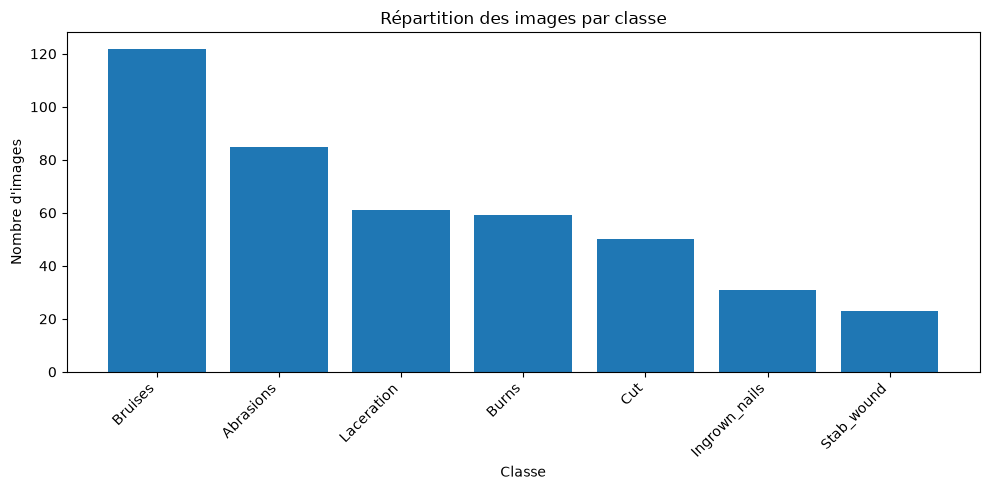

In [5]:
FIGURES_DIR = Path("../reports/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(10, 5))
plt.bar(class_distribution["class"], class_distribution["count"])
plt.xticks(rotation=45, ha="right")
plt.title("Répartition des images par classe")
plt.xlabel("Classe")
plt.ylabel("Nombre d'images")
plt.tight_layout()

plt.savefig(FIGURES_DIR / "class_distribution.png", dpi=300)
plt.show()

In [6]:
max_count = class_distribution["count"].max()
min_count = class_distribution["count"].min()
imbalance_ratio = max_count / min_count

print(f"Classe majoritaire : {max_count} images")
print(f"Classe minoritaire : {min_count} images")
print(f"Ratio de déséquilibre max/min : {imbalance_ratio:.2f}")

Classe majoritaire : 122 images
Classe minoritaire : 23 images
Ratio de déséquilibre max/min : 5.30


In [7]:
resolution_stats = df[["width", "height", "ratio"]].describe()
resolution_stats

,width,height,ratio
count,431.0,431.0,431.0
mean,640.0,640.0,1.0
std,0.0,0.0,0.0
min,640.0,640.0,1.0
25%,640.0,640.0,1.0
50%,640.0,640.0,1.0
75%,640.0,640.0,1.0
max,640.0,640.0,1.0


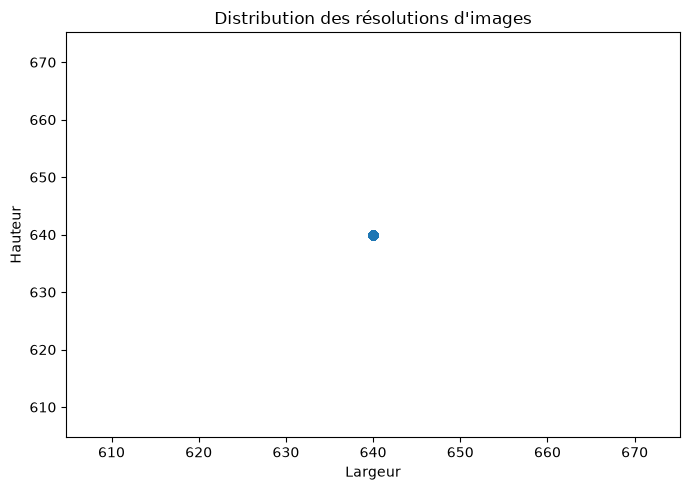

In [8]:
# Analyse des résolutions

plt.figure(figsize=(7, 5))
plt.scatter(df["width"], df["height"], alpha=0.4)
plt.title("Distribution des résolutions d'images")
plt.xlabel("Largeur")
plt.ylabel("Hauteur")
plt.tight_layout()
plt.show()

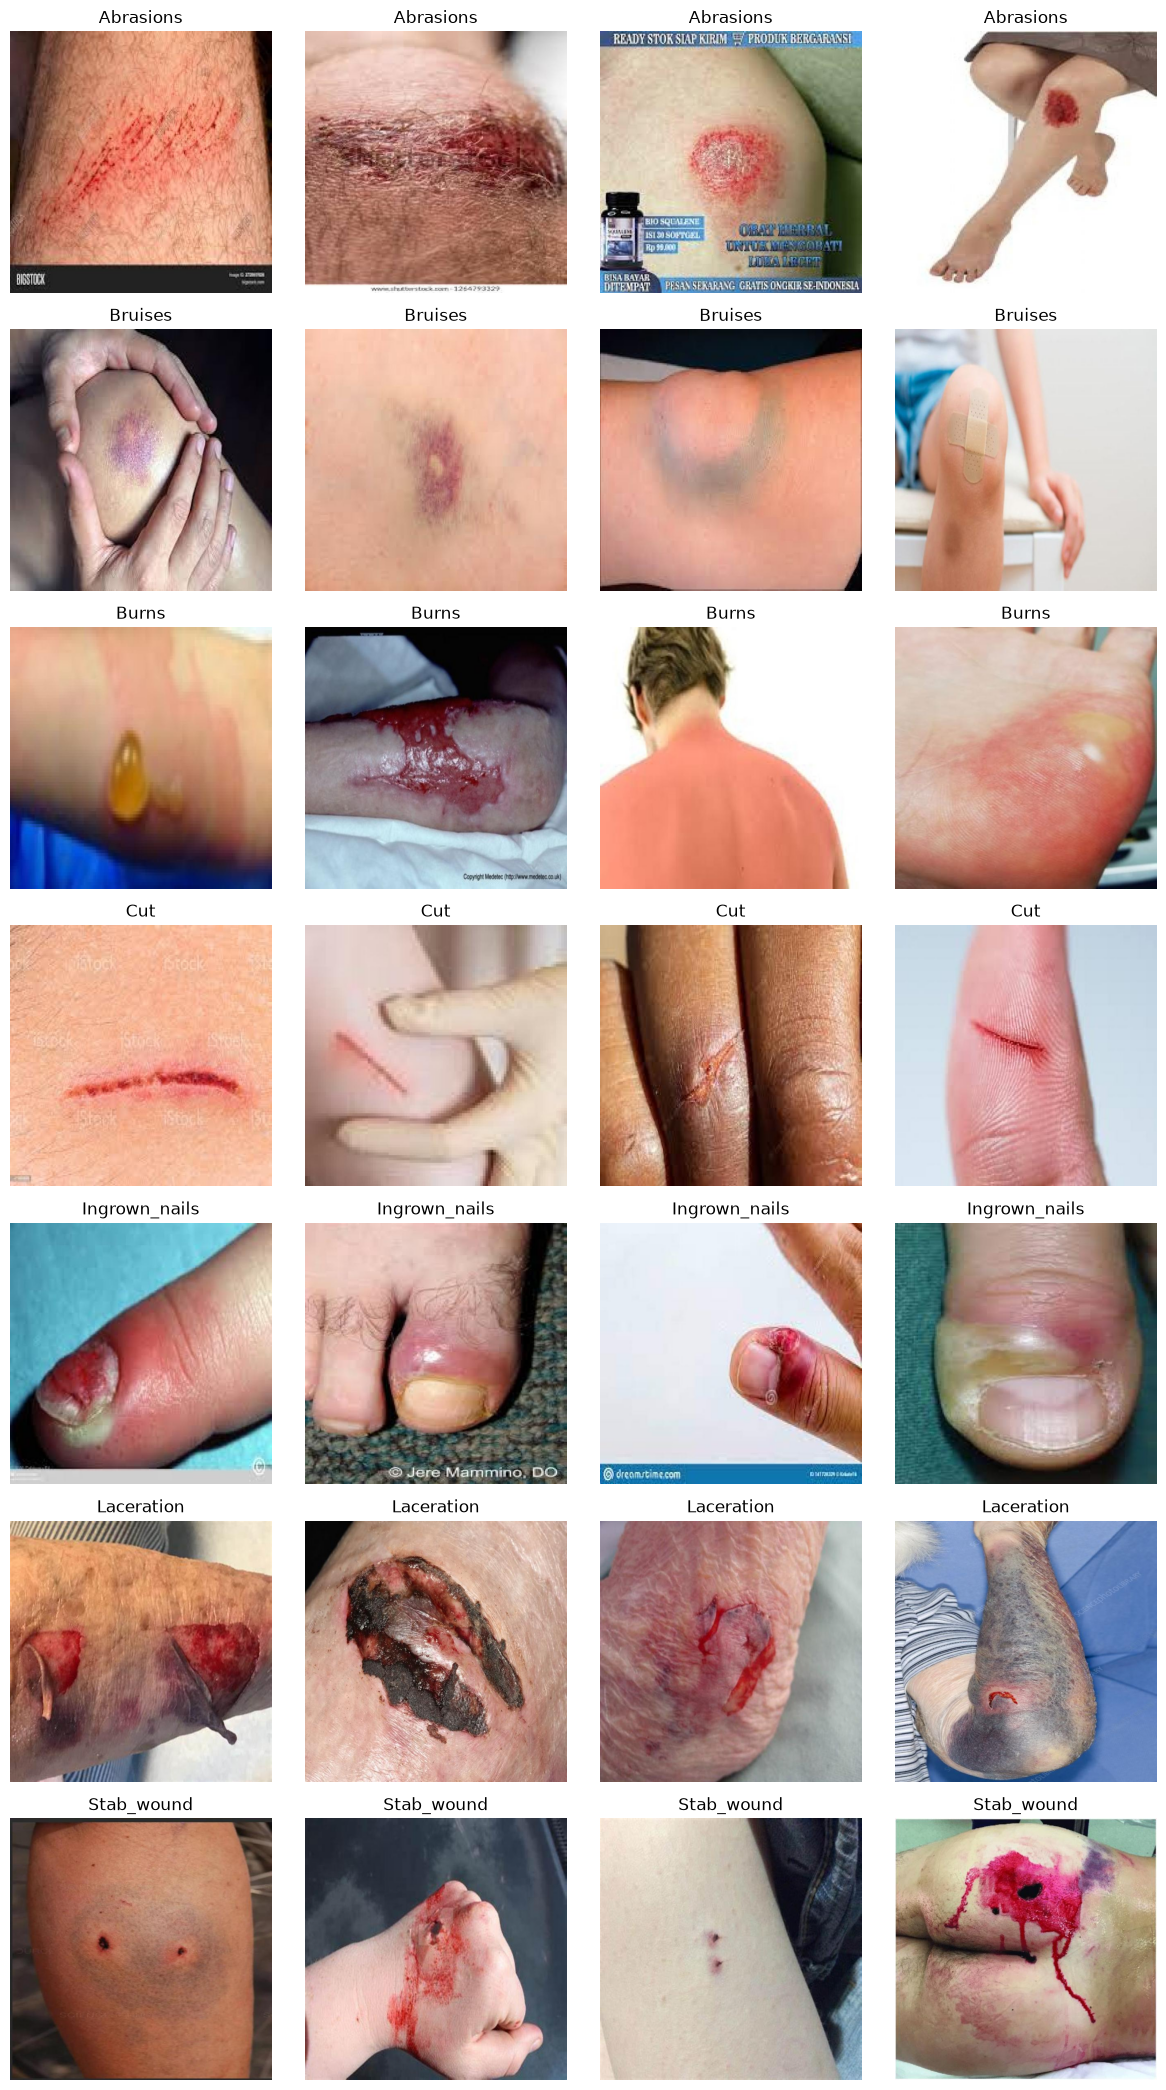

In [ ]:
def show_examples_per_class(df, n=4, seed=42):

    classes = sorted(df["class"].unique())
    
    fig, axes = plt.subplots(
        len(classes), 
        n, 
        figsize=(3 * n, 3 * len(classes))
    )
    
    if len(classes) == 1:
        axes = np.expand_dims(axes, axis=0)
    
    for row_idx, class_name in enumerate(classes):
        class_df = df[df["class"] == class_name]
        sample_df = class_df.sample(
            n=min(n, len(class_df)), 
            random_state=seed
        )
        
        for col_idx in range(n):
            ax = axes[row_idx, col_idx]
            ax.axis("off")
            
            if col_idx < len(sample_df):
                img_path = sample_df.iloc[col_idx]["path"]
                img = Image.open(img_path).convert("RGB")
                ax.imshow(img)
                ax.set_title(class_name)
    
    plt.tight_layout()
    plt.show()

show_examples_per_class(df, n=4)

In [10]:
summary = {
    "total_images": len(df),
    "num_classes": df["class"].nunique(),
    "min_images_per_class": int(min_count),
    "max_images_per_class": int(max_count),
    "imbalance_ratio": round(float(imbalance_ratio), 2),
    "median_width": int(df["width"].median()),
    "median_height": int(df["height"].median()),
    "num_invalid_files": len(df_invalid)
}

summary

{'total_images': 431,
 'num_classes': 7,
 'min_images_per_class': 23,
 'max_images_per_class': 122,
 'imbalance_ratio': 5.3,
 'median_width': 640,
 'median_height': 640,
 'num_invalid_files': 0}

In [11]:
if imbalance_ratio < 1.5:
    balance_conclusion = "Le dataset peut être considéré comme globalement équilibré."
elif imbalance_ratio < 3:
    balance_conclusion = "Le dataset présente un déséquilibre modéré entre les classes."
else:
    balance_conclusion = "Le dataset présente un déséquilibre important entre les classes."

print(balance_conclusion)
print(
    f"Le dataset contient {summary['total_images']} images réparties en "
    f"{summary['num_classes']} classes. Le nombre d'images par classe varie "
    f"de {summary['min_images_per_class']} à {summary['max_images_per_class']}, "
    f"soit un ratio max/min de {summary['imbalance_ratio']}."
)

Le dataset présente un déséquilibre important entre les classes.
Le dataset contient 431 images réparties en 7 classes. Le nombre d'images par classe varie de 23 à 122, soit un ratio max/min de 5.3.


In [12]:
from sklearn.model_selection import train_test_split

# Premier split : train / temp
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["class"],
    random_state=42
)

# Deuxième split : validation / test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["class"],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

split_distribution = pd.DataFrame({
    "train": train_df["class"].value_counts(),
    "validation": val_df["class"].value_counts(),
    "test": test_df["class"].value_counts()
}).fillna(0).astype(int)

split_distribution["total"] = split_distribution.sum(axis=1)
split_distribution

Train: 301
Validation: 65
Test: 65


,train,validation,test,total
class,,,,
Abrasions,59,13,13,85
Bruises,85,18,19,122
Burns,41,9,9,59
Cut,35,8,7,50
Ingrown_nails,22,4,5,31
Laceration,43,9,9,61
Stab_wound,16,4,3,23


In [13]:
split_percentages = (
    split_distribution[["train", "validation", "test"]]
    .div(split_distribution["total"], axis=0) * 100
)

split_percentages.round(2)

,train,validation,test
class,,,
Abrasions,69.41,15.29,15.29
Bruises,69.67,14.75,15.57
Burns,69.49,15.25,15.25
Cut,70.00,16.00,14.00
Ingrown_nails,70.97,12.90,16.13
Laceration,70.49,14.75,14.75
Stab_wound,69.57,17.39,13.04


In [14]:
SPLIT_DIR = Path("../data/processed/splits")
SPLIT_DIR.mkdir(parents=True, exist_ok=True)

train_df.to_csv(SPLIT_DIR / "train.csv", index=False)
val_df.to_csv(SPLIT_DIR / "val.csv", index=False)
test_df.to_csv(SPLIT_DIR / "test.csv", index=False)

print("Splits sauvegardés dans :", SPLIT_DIR.resolve())

Splits sauvegardés dans : /Users/hugo/Dev/CNN_Hopital/data/processed/splits


## Conclusion de l'analyse exploratoire

Le dataset contient 431 images réparties en 7 classes de plaies. Aucune image illisible n'a été détectée, ce qui permet d'utiliser l'ensemble des fichiers disponibles pour la suite du projet.

La distribution des classes est fortement déséquilibrée. La classe majoritaire, `Bruises`, contient 122 images, soit 28,31 % du dataset, tandis que la classe minoritaire, `Stab_wound`, ne contient que 23 images, soit 5,34 %. Le ratio entre la classe majoritaire et la classe minoritaire est donc de 5,3. Ce déséquilibre peut biaiser l'apprentissage du CNN en faveur des classes les plus représentées et dégrader le rappel ou le F1-score des classes minoritaires.

Les images présentent une résolution médiane de 640 × 640 pixels. Elles seront redimensionnées en 224 × 224 pixels afin de standardiser les entrées et de rester compatibles avec les architectures CNN pré-entraînées utilisées en transfer learning, notamment ResNet, VGG ou EfficientNet. Ce choix permet de conserver une information visuelle suffisante tout en limitant le coût d'entraînement.

Le dataset est séparé en trois sous-ensembles train, validation et test selon une répartition 70 % / 15 % / 15 %. Le split est stratifié afin de conserver la proportion des classes dans chaque sous-ensemble, ce qui est particulièrement important compte tenu du déséquilibre initial.

Pour limiter ce risque, seules les images d'entraînement feront l'objet d'augmentations. Deux stratégies de rééquilibrage seront comparées dans la suite du projet : l'échantillonnage pondéré via `WeightedRandomSampler` et la pondération de la fonction de perte avec des poids de classes.